Plan is the following

1. Trying the PS on binomial Gaussuan in D- dimensions $(D=10, \, 10^2, \, 10^3, \, 10^4)$ for a target distribution 

$p(\theta | y) = \frac{1}{3} \mathcal{N}(0, 1) + \frac{2}{3} \mathcal{N}(\sqrt{D}, 1 / 2)$.

with prior $\pi(\theta) = \mathcal{U}(\theta | -4\sqrt{D}, 4\sqrt{D})$

and the Likelihood function $\mathcal{L}(\theta) = p(y| \theta) =  \frac{1}{3} \mathcal{N}(0, 1) + \frac{2}{3} \mathcal{N}(\sqrt{D}, 1 / 2)$

2. Experiment is Rosenbrock Function (non-convex) optimization benchmark, that is chalangenging as it has a curved narrow valley with  the minimum. A variant with $D$ dimensions has a log- likelihood function given by $\log \mathcal{L}(\mathbb{\theta}) = - \sum_{i=1}^{D/2} [10(\theta_{2i+1}^{2} - \theta_{2i})^2 + (\theta_{2i-1} - 1 )^2] $

with a prior,a multivariate normal distribution $\pi (\mathbb{\theta}) = \mathcal{N}(0, 5^{2} \mathbb{I})$.

3. Experiment is Sparse Logistic Regression on German Credit Dataset (1000 individuals, 24 fetures and binary outcome designed for credit risk prediction). The data was preprocessed by standardizing the fetures ($(X - \bar{X})/ \sigma$). parameters are sampled in log-space $u = \log \tau$, $v = \log \lambda$ (don't forget the Jacobian correction).

Likelihood function is $\mathcal{L}(\mathbb{y} | \mathbb{\beta}, \mathbb{\lambda}, \tau )= \prod_{i=1}^{1000} \text{Bernoulli}(y_{i} | \sigma((\tau  \mathbb{\lambda} \odot  \mathbb{\beta})^{T} X_{i})) $

$\sigma(.)$ is sigmoid function, $\mathbb{\beta},\, \mathbb{\lambda}$ are 25 dim vectors, $\tau$ is a scalar.

The priors are: $\pi (\mathbb{\beta}, \mathbb{\lambda}, \tau) = \text{Gamma}(\tau| 0.5, \, 0.5) \times \prod_{j=1}^{25} \mathcal{N}(\beta_{j}|0,1) \text{Gamma}(\lambda_{j}| 0.5, \, 0.5)$



Minas propeses trying PS in combination with HMC/LMC(ULA, MALA)/NUTS/MCLMC/etc and compare that to: SMC and perhaps Parallel Tempering.

maby if there is time I could also try: ULA, diagonal preconditioned ULA, diagonal preconditioned HMC or MALA, low-rank / dense adaptive mass matrix

Quality evaluation 

I will use the same metrices as is done in PS paper, by calculating $MSE$ for:
- bias and variance of first $f_{1}(\theta) = \theta$ and second $f_{2}(\theta) = \theta^2$ posterior moment.
- log marginal likelihood estimate $\log \mathcal{Z}$ 

for $\log \mathcal{Z}$ the MSE is computed across $L=100$ independent runs

$$MSE_{\log \mathcal{Z}} = \frac{1}{L} \sum_{l=1}^{L} (\log \mathcal{Z}_l - \log \mathcal{Z})^2,$$

the $\log \mathcal{Z}$ is a reference value computed from 100 independent runs of $10^{4}$ particles SMC, where we set value to $\alpha = 0.999$ (this paramether has a role in the adaptive tempering schedule, controlling the ESS threshold).

again same as in the PS paper, for D-dim posterior moments I calculated the maximum squared bias across dimensions:

$$ b_{i}^{2} = \max_{d} ( \frac{\hat{f}_{i,d} - \mu (f_{i,d})}{\sigma (f_{i,d})} )^{2} $$

where $\hat{f}_{i,d}$ is the estimated coordiate - wise mean across $L=100$ independent runs, while $\mu(f_{i,d})$, $\sigma(f_{i,d})$ are the mean and standard deviation of the coordinate-wise posterior moment $f_{i,d}$ computed from 100 independent runs of $10^{4}$ particles SMC.

additional metrices to keep an eye on: ESS per second, ESS per dim min/median, ESS/gradient eval, MSE of $\theta$ and $\theta^{2}$, gradient evaluation counts, variance of log weights,acceptance rate (kernel), number of resampling steps, log evidence variance, ESJD, ESS trajectory over anenealing steps, weight entropy, time-to-ESS, Wasserstein distance or KSD


projects structure:
```text
code/
├── targets.py          # prior, likelihood, exact/analytic moments if available
├── samplers.py         # wrappers for PS+HMC, PS+ HMC/LMC/NUTS/MCLMC/etc
├── metrics.py          # one-run metrics and multi-run aggregations
├── reference.py        # builds/stores reference moments and reference logZ
├── experiment.py       # loops over D, sampler, kernel, seeds
└── plots.py            # plotting of results to compare the kernels
```

**targets.py**

For now I have only Multymodal Gauss experiment implemented. Here I define the target distribution, the prior, the likelihood, posterior and how to sample initial particles form the posterior. 

We have a Target dataclass that combines the prior, likelihood, posterior, and prior-sampling functions. In the current experiment, the target is a 
D-dimensional bimodal Gaussian mixture likelihood combined with a uniform-box prior 
$[- 4 \sqrt{D},  4 \sqrt{D}]^{D}$. For the sanity check we als o provide the approximate mixture-based formulas for the posterior mean and second moment.

**reference.py** 

We have an adaptive tempered (how we update temperature) Sequential Monte Carlo sampler. It uses systematic resampling and a Random-Walk Metropolis move kernel. The random-walk proposal covariance is estimated from the particle cloud, and the proposal scale is tuned by Robbins-Monro adaptation toward a target acceptance rate (total number of RM updates k(T-1) and the diminishing schedule is local to each SMC iteration). It estimates posterior moments and the log evidence. 
The code is paralelised to run many (num\_workers) seeds simultaniously using CPU cores, later aggregating the results into a stable reference estimate.

the code does not yet support: ESJD, weight entropy, Wasserstein, KSD, gradient-eval counts, ESS/gradient eval, variance of log weights, explicit resampling counts

**samplers.py** 

for each of the cobinations PS + RW/HMC/LMC(ULA + MALA)/NUTS/MCLMC/etc calculate: 
logZ
posterior_mean
posterior_second_moment
final_ess
acceptance_rate_mean
n_iter
runtime_sec
tempering_path
logZ_path
ess_path
acceptance_path
elapsed_time_path
gradient_eval_count
resampling_steps
variance_log_weights_path
weight_entropy_path
esjd_path

the PS has to be adaptive tempered as it is defined in the PS paper [see page 5]. 





In [ ]:
import numpy as np
# setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
import blackjax
from blackjax.smc.persistent_sampling import compute_persistent_ess
from blackjax.smc.resampling import systematic
from blackjax.smc import extend_params

# linear temepering schedule
def log_prior(theta: jnp.ndarray, d: int) -> jnp.ndarray:
    bound = jnp.sqrt(float(d))
    logpdf_coords = jax.scipy.stats.uniform.logpdf(
        theta,
        loc=-bound,
        scale=2.0 * bound,
    )
    return jnp.sum(logpdf_coords)

def log_gaussian_diag(x: jnp.ndarray, mean: jnp.ndarray, var: float) -> jnp.ndarray:
    return -0.5 * (
        jnp.sum((x - mean) ** 2 / var)
        + x.shape[-1] * jnp.log(2.0 * jnp.pi * var)
    )

def log_likelihood(theta: jnp.ndarray, d: int) -> jnp.ndarray:
    mean1 = jnp.zeros(d)
    mean2 = jnp.sqrt(float(d)) * jnp.ones(d)

    log_prob1 = log_gaussian_diag(theta, mean1, 1.0)
    log_prob2 = log_gaussian_diag(theta, mean2, 0.5)

    return jax.scipy.special.logsumexp(
        jnp.array([log_prob1, log_prob2]),
        b=jnp.array([1/3, 2/3]),
    )

def log_posterior(theta: jnp.ndarray, d: int) -> jnp.ndarray:
    return log_prior(theta, d) + log_likelihood(theta, d)

# dim=10, t= 3.2sec
dimension = 100

# SMC configuration
num_particles = 1000

log_prior_fn = lambda theta: log_prior(theta, dimension)
log_likelihood_fn = lambda theta: log_likelihood(theta, dimension)
log_posterior_fn = lambda theta: log_posterior(theta, dimension)



# define fixed linear tempering schedule
num_temperatures = 100
tempering_schedule = jnp.linspace(0.0, 1.0, num_temperatures)
# Set random seed
key = jax.random.PRNGKey(42)

key, init_key = jax.random.split(key)
initial_particles = jax.random.uniform( init_key,
                                        shape = (num_particles, dimension),
                                        minval = -jnp.sqrt(jnp.array([dimension])), 
                                        maxval = jnp.sqrt(jnp.array([dimension])), )

# HMC parameters for MCMC moves
hmc_parameters = { "step_size": 0.02,
                    "inverse_mass_matrix": jnp.ones(dimension), 
                    "num_integration_steps": 100, }


# create Persistent Sampling kernel
ps_kernel = blackjax.persistent_sampling_smc(   logprior_fn=log_prior_fn,
                                                loglikelihood_fn=log_likelihood_fn,
                                                n_schedule=num_temperatures,
                                                mcmc_step_fn=blackjax.hmc.build_kernel(), # HMC 
                                                mcmc_init_fn=blackjax.hmc.init, 
                                                mcmc_parameters=extend_params(hmc_parameters),
                                                resampling_fn=systematic,
                                                num_mcmc_steps=25, )

# create inference loop
def inference_loop(key, kernel, initial_state, schedule): # SMC inference loop 

    def one_step(carry, lmbda):
        key, state = carry
        key, step_key = jax.random.split(key)
        new_state, _ = kernel.step(step_key, state, lmbda)
        ess = compute_persistent_ess( jnp.log(new_state.persistent_weights), normalize_weights=True )
        return (key, new_state), ess

    init_state = kernel.init(initial_state)
    (_, final_state), ess_history = jax.lax.scan(one_step, (key, init_state), schedule)
    return final_state, ess_history

key, ps_key = jax.random.split(key)
ps_final_state, ess_history = inference_loop(
    ps_key,
    ps_kernel,
    initial_particles,
    tempering_schedule,
)

ps_ess = compute_persistent_ess(
    jnp.log(ps_final_state.persistent_weights), normalize_weights=True
)
print(f"Persistent Sampling Results:")
print(
    f"  Final ESS: {ps_ess:.1f} (from {num_particles * num_temperatures} persistent particles, {ps_ess/(num_particles * num_temperatures):.2%})"
)
print(f"  Log evidence estimate: {ps_final_state.log_Z:.2f}\n")

Persistent Sampling Results:
  Final ESS: 15267.5 (from 100000 persistent particles, 15.27%)
  Log evidence estimate: -301.64



In [ ]:
#β_t is computed internally from the ESS condition using bisection

import jax
import jax.numpy as jnp
import blackjax
import blackjax.smc.resampling as resampling
from blackjax.smc import extend_params

dimension = 15

def log_prior(theta, d):
    bound = jnp.sqrt(float(d))
    logpdf_coords = jax.scipy.stats.uniform.logpdf(
        theta, loc=-bound, scale=2.0 * bound
    )
    return jnp.sum(logpdf_coords)

def log_gaussian_diag(x, mean, var):
    return -0.5 * (
        jnp.sum((x - mean) ** 2 / var)
        + x.shape[-1] * jnp.log(2.0 * jnp.pi * var)
    )

def log_likelihood(theta, d):
    mean1 = jnp.zeros(d)
    mean2 = jnp.sqrt(float(d)) * jnp.ones(d)

    log_prob1 = log_gaussian_diag(theta, mean1, 1.0)
    log_prob2 = log_gaussian_diag(theta, mean2, 0.5)

    return jax.scipy.special.logsumexp(
        jnp.array([log_prob1, log_prob2]),
        b=jnp.array([1.0 / 3.0, 2.0 / 3.0]),
    )

log_prior_fn = lambda theta: log_prior(theta, dimension)
log_likelihood_fn = lambda theta: log_likelihood(theta, dimension)

num_particles = 32
max_iterations = 100
alpha = 0.999   # paper notation

key = jax.random.PRNGKey(42)
key, init_key = jax.random.split(key)

bound = jnp.sqrt(float(dimension))
initial_particles = jax.random.uniform(
    init_key,
    shape=(num_particles, dimension),
    minval=-bound,
    maxval=bound,
)

hmc_parameters = {
    "step_size": 0.001,
    "inverse_mass_matrix": jnp.ones(dimension),
    "num_integration_steps": 20,
}

adaptive_ps_kernel = blackjax.adaptive_persistent_sampling_smc(
    logprior_fn=log_prior_fn,
    loglikelihood_fn=log_likelihood_fn,
    max_iterations=max_iterations,
    mcmc_step_fn=blackjax.hmc.build_kernel(),
    mcmc_init_fn=blackjax.hmc.init,
    mcmc_parameters=extend_params(hmc_parameters),
    resampling_fn=resampling.systematic,
    target_ess=alpha,
    num_mcmc_steps=25,
)

def adaptive_loop(key, kernel, initial_particles, max_iterations):
    init_state = kernel.init(initial_particles)

    def cond_fun(carry): # stopping rule
        i, state, _ = carry
        return (state.tempering_param < 1.0) & (i < max_iterations)

    def body_fun(carry):
        i, state, key = carry
        key, subkey = jax.random.split(key)
        new_state, info = kernel.step(subkey, state) # new step is internaly calculated 
        return i + 1, new_state, key

    n_iter, final_state, _ = jax.lax.while_loop(
        cond_fun,
        body_fun,
        (0, init_state, key),
    )
    return n_iter, final_state

key, run_key = jax.random.split(key)
n_iter, ps_final_state = adaptive_loop(
    run_key,
    adaptive_ps_kernel,
    initial_particles,
    max_iterations,
)

# optional: remove unused padding
ps_final_state = blackjax.persistent_sampling.remove_padding(ps_final_state)

print("n_iter =", n_iter)
print("final beta =", ps_final_state.tempering_param)
print("log_Z =", ps_final_state.log_Z)

n_iter = 5
final beta = 1.0
log_Z = -36.844704


In [2]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print(jax.devices())

from reference import build_reference_stats_chunked

ref = build_reference_stats_chunked(
    dimension=10,
    num_particles_reference=32,
    num_reference_runs=10,
    chunk_size=5,
    max_iterations=200,
    alpha=0.9,
    num_mcmc_steps=5,
    rw_step_size=0.2,
)

print("logZ_ref_mean:", ref.logZ_ref_mean)
print("logZ_ref_std:", ref.logZ_ref_std)
print("final_ess_mean:", ref.final_ess_mean)
print("acceptance_rate_mean:", ref.acceptance_rate_mean)
print("n_iter_mean:", ref.n_iter_mean)

[CpuDevice(id=0)]
Running reference chunk 0:5
Running reference chunk 5:10
logZ_ref_mean: -10.486807537078857
logZ_ref_std: 0.02029896586745094
final_ess_mean: 31.7930419921875
acceptance_rate_mean: 0.9982144951820373
n_iter_mean: 2.0


In [ ]:
"""from reference import build_reference_stats_chunked, load_reference_stats, nan_report_reference_stats

ref = build_reference_stats_chunked(
    dimension=10,
    num_particles_reference=32,
    num_reference_runs=10,
    chunk_size=5,
    max_iterations=200,
    alpha=0.9,
    num_mcmc_steps=5,
    rw_step_size=0.5,
    checkpoint_path="../data/checkpoints/ref_dim10_ckpt.json",
    save_final_path="../data/checkpoints/ref_dim10_final.json",
)

print("logZ_ref_mean:", ref.logZ_ref_mean)
print("logZ_ref_std:", ref.logZ_ref_std)
print("final_ess_mean:", ref.final_ess_mean)
print("acceptance_rate_mean:", ref.acceptance_rate_mean)
print("n_iter_mean:", ref.n_iter_mean)

print("\nNaN report from in-memory object:")
print(nan_report_reference_stats(ref))"""

"""from reference import run_reference_sampler_once

out = run_reference_sampler_once(
    dimension=10,
    num_particles=32,
    seed=0,
    max_iterations=200,
    alpha=0.9,
    num_mcmc_steps=10,
    rw_step_size=2.0,
    rm_c=5.0,
    rm_t0=1.0,
    rm_kappa=0.6,)


print(out["acceptance_rate_mean"])
print(out["rw_scale_path"])"""



import os

# Must be set BEFORE importing jax/reference
os.environ["JAX_PLATFORM_NAME"] = "cpu"

from reference import build_reference_stats_chunked
import jax

print(jax.default_backend())
print(jax.devices())

ref = build_reference_stats_chunked(
    dimension=10,
    num_particles_reference=10,
    num_reference_runs=8,
    chunk_size=4,
    parallel=True,
    num_workers=2,
    checkpoint_path=None,
    save_final_path=None,
    max_iterations=200,
    alpha=0.9,
    num_mcmc_steps=10,
    rw_step_size=2.0,
    rm_c=5.0,
    rm_t0=1.0,
    rm_kappa=0.6,
    verbose=True,
)

ref

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1775597418.158995 26982358 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1775597418.210606 26982358 service.cc:145] XLA service 0x1173fe3a0 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775597418.210796 26982358 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1775597418.212678 26982358 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1775597418.212708 26982358 mps_client.cc:384] XLA backend will use up to 11452858368 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB

cpu
[CpuDevice(id=0)]
Running reference chunk seeds 0:4


Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1775597419.789782 26982811 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
W0000 00:00:1775597419.789816 26982809 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1775597419.798436 26982811 service.cc:145] XLA service 0x102f926a0 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775597419.798443 26982809 service.cc:145] XLA service 0x14d1e8be0 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775597419.798449 26982811 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1775597419.798451 26982809 service.cc:153]   Stre

Metal device set to: Metal device set to: Apple M1 ProApple M1 Pro


systemMemory: 16.00 GB
maxCacheSize: 5.33 GB


systemMemory: 16.00 GB
maxCacheSize: 5.33 GB

Run 1/8 completed (seed=1) | elapsed=9.9s | ETA=69.6s
Run 2/8 completed (seed=0) | elapsed=10.1s | ETA=30.3s
Run 3/8 completed (seed=2) | elapsed=14.9s | ETA=24.9s
Run 4/8 completed (seed=3) | elapsed=15.2s | ETA=15.2s


I0000 00:00:1775597433.904781 26982811 mps_client.h:209] MetalClient destroyed.
I0000 00:00:1775597433.905573 26982809 mps_client.h:209] MetalClient destroyed.


Running reference chunk seeds 4:8


Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1775597435.671961 26983075 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1775597435.672038 26983073 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1775597435.680565 26983075 service.cc:145] XLA service 0x17256b650 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775597435.680580 26983075 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1775597435.680568 26983073 service.cc:145] XLA service 0x161047180 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775597435.680589 26983073 service.cc:153]   Stre

Metal device set to: Metal device set to: Apple M1 Pro
Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB


systemMemory: 16.00 GB
maxCacheSize: 5.33 GB

Run 5/8 completed (seed=4) | elapsed=24.7s | ETA=14.8s
Run 6/8 completed (seed=5) | elapsed=24.8s | ETA=8.3s
Run 7/8 completed (seed=6) | elapsed=28.6s | ETA=4.1s
Run 8/8 completed (seed=7) | elapsed=29.3s | ETA=0.0s


I0000 00:00:1775597447.986128 26983073 mps_client.h:209] MetalClient destroyed.
I0000 00:00:1775597447.997627 26983075 mps_client.h:209] MetalClient destroyed.


ReferenceStats(target_name='gaussian_mixture', dimension=10, num_reference_runs=8, num_particles_reference=10, logZ_ref_mean=-14.82721921801567, logZ_ref_std=0.27739017217749556, f1_mean_ref=array([-0.13665238, -0.11467347, -0.12024808,  0.07674778,  0.10789358,
       -0.00690053,  0.0491311 , -0.04753275,  0.11270276, -0.15135184],
      dtype=float32), f1_std_ref=array([0.2023211 , 0.2889461 , 0.22826041, 0.2122896 , 0.1046873 ,
       0.14235917, 0.16381192, 0.2811834 , 0.17379533, 0.18266797],
      dtype=float32), f2_mean_ref=array([0.36933744, 0.31083322, 0.42252302, 0.32446432, 0.3881883 ,
       0.27082714, 0.51809275, 0.34332392, 0.31191427, 0.3404752 ],
      dtype=float32), f2_std_ref=array([0.06912333, 0.30184203, 0.2565847 , 0.20131138, 0.22619368,
       0.15975286, 0.2527439 , 0.22957867, 0.23152867, 0.2419123 ],
      dtype=float32), final_ess_mean=9.861634254455566, final_ess_std=0.15848610866668783, acceptance_rate_mean=0.23911158846818753, acceptance_rate_std=0.0082

Running target=gaussian_mixture, kernel=RWM ...
Running target=gaussian_mixture, kernel=HMC ...
Running target=gaussian_mixture, kernel=ULA ...
Running target=gaussian_mixture, kernel=MALA ...
Traceback (most recent call last):
  File "/var/folders/nw/25jg1by51wl9cgh02mtcnt640000gn/T/ipykernel_51764/3979111129.py", line 161, in <module>
    out = run_fn(target)
          ^^^^^^^^^^^^^^
  File "/var/folders/nw/25jg1by51wl9cgh02mtcnt640000gn/T/ipykernel_51764/3979111129.py", line 102, in run_mala
    return samplers_beta.run_ps_mala_once(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/makskoncilja/Documents/fmf/druga_stopnja/magistrska/project/code/samplers_beta.py", line 1046, in run_ps_mala_once
    return _run_ps_generic_once(
           ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/makskoncilja/Documents/fmf/druga_stopnja/magistrska/project/code/samplers_beta.py", line 340, in _run_ps_generic_once
    state, info = kernel.step(subkey, state)
                  ^^^^^^^^^^^^^^^^^^^^^^

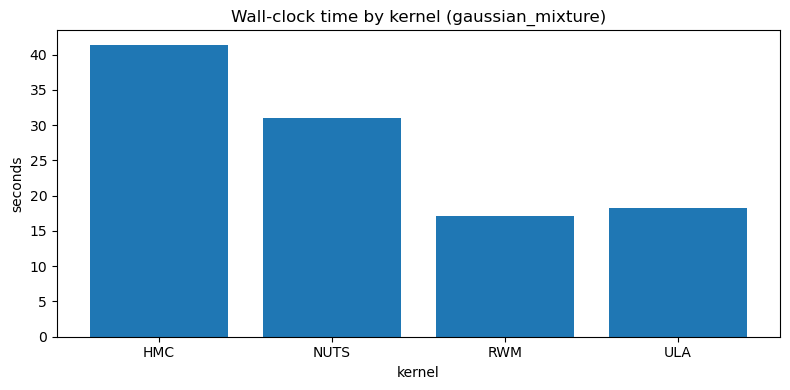

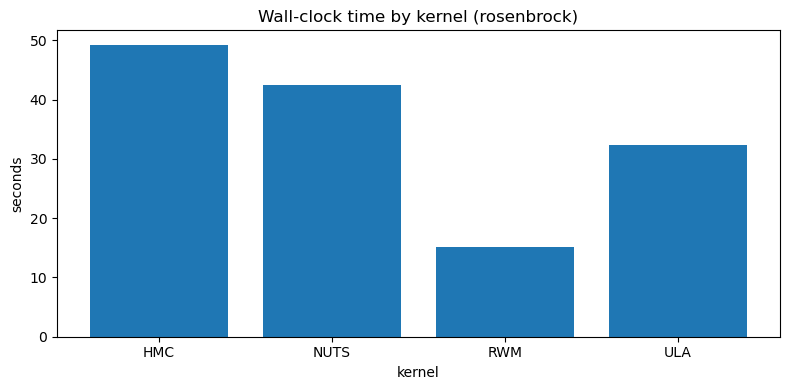

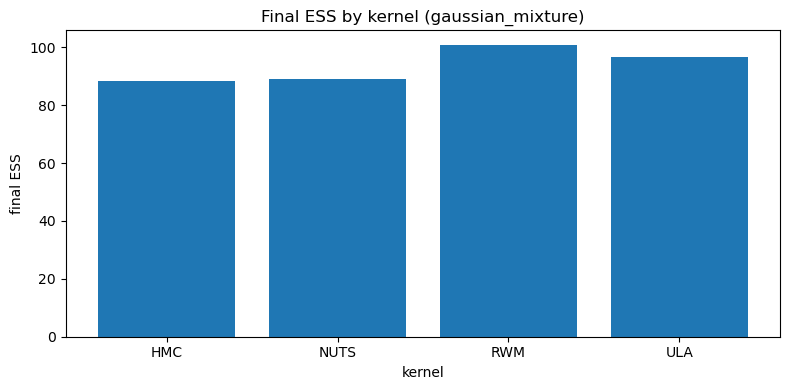

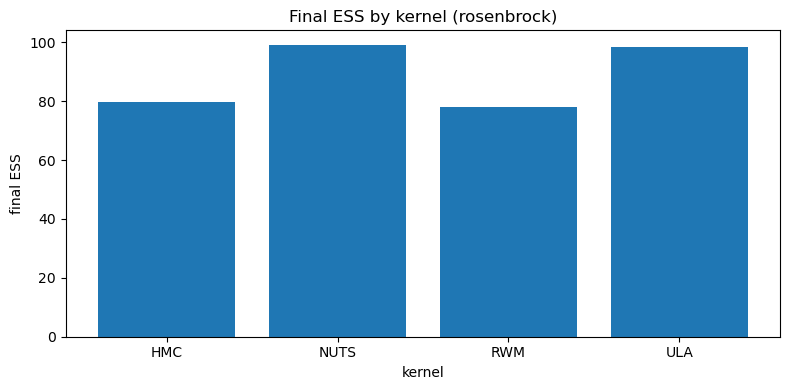

In [1]:
import time
import traceback
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import samplers_beta
import targets

importlib.reload(samplers_beta)
importlib.reload(targets)

from targets import make_gaussian_mixture_target, make_rosenbrock_target

SEED = 0
NUM_MCMC_STEPS = 10

DIMENSION = 8          # Rosenbrock needs even dimension
NUM_PARTICLES = 32
MAX_ITERATIONS = 1000
ALPHA = 0.999

# RW
RW_STEP_SIZE = 1.0
RW_TARGET_ACCEPT = 0.234

# HMC
HMC_STEP_SIZE = 0.1
HMC_NUM_INTEGRATION_STEPS = 10
HMC_TARGET_ACCEPT = 0.651

# ULA
ULA_STEP_SIZE = 5e-3

# MALA
MALA_STEP_SIZE = 0.02
MALA_TARGET_ACCEPT = 0.574

# NUTS
NUTS_STEP_SIZE = 0.1
NUTS_MAX_NUM_DOUBLINGS = 10
NUTS_TARGET_ACCEPT = 0.8

# MCLMC
MCLMC_STEP_SIZE = 1e-2
MCLMC_L = 1.0

MASS_MATRIX_RIDGE = 1e-6

target_builders = {
    "gaussian_mixture": lambda: make_gaussian_mixture_target(DIMENSION),
    "rosenbrock": lambda: make_rosenbrock_target(DIMENSION),
}

targets_dict = {name: builder() for name, builder in target_builders.items()}
targets_dict

def run_rwm(target):
    return samplers_beta.run_ps_rwm_once(
        dimension=target.dimension,
        num_particles=NUM_PARTICLES,
        seed=SEED,
        target=target,
        max_iterations=MAX_ITERATIONS,
        alpha=ALPHA,
        num_mcmc_steps=NUM_MCMC_STEPS,
        rw_step_size=RW_STEP_SIZE,
        target_acceptance_rate=RW_TARGET_ACCEPT,
    )

def run_hmc(target):
    return samplers_beta.run_ps_hmc_once(
        dimension=target.dimension,
        num_particles=NUM_PARTICLES,
        seed=SEED,
        target=target,
        max_iterations=MAX_ITERATIONS,
        alpha=ALPHA,
        num_mcmc_steps=NUM_MCMC_STEPS,
        step_size=HMC_STEP_SIZE,
        num_integration_steps=HMC_NUM_INTEGRATION_STEPS,
        target_acceptance_rate=HMC_TARGET_ACCEPT,
        mass_matrix_ridge=MASS_MATRIX_RIDGE,
    )

def run_ula(target):
    return samplers_beta.run_ps_ula_once(
        dimension=target.dimension,
        num_particles=NUM_PARTICLES,
        seed=SEED,
        target=target,
        max_iterations=MAX_ITERATIONS,
        alpha=ALPHA,
        num_mcmc_steps=NUM_MCMC_STEPS,
        step_size=ULA_STEP_SIZE,
    )

def run_mala(target):
    return samplers_beta.run_ps_mala_once(
        dimension=target.dimension,
        num_particles=NUM_PARTICLES,
        seed=SEED,
        target=target,
        max_iterations=MAX_ITERATIONS,
        alpha=ALPHA,
        num_mcmc_steps=NUM_MCMC_STEPS,
        step_size=MALA_STEP_SIZE,
        target_acceptance_rate=MALA_TARGET_ACCEPT,
    )

def run_nuts(target):
    return samplers_beta.run_ps_nuts_once(
        dimension=target.dimension,
        num_particles=NUM_PARTICLES,
        seed=SEED,
        target=target,
        max_iterations=MAX_ITERATIONS,
        alpha=ALPHA,
        num_mcmc_steps=NUM_MCMC_STEPS,
        step_size=NUTS_STEP_SIZE,
        max_num_doublings=NUTS_MAX_NUM_DOUBLINGS,
        target_acceptance_rate=NUTS_TARGET_ACCEPT,
        mass_matrix_ridge=MASS_MATRIX_RIDGE,
    )

def run_mclmc(target):
    return samplers_beta.run_ps_mclmc_once(
        dimension=target.dimension,
        num_particles=NUM_PARTICLES,
        seed=SEED,
        target=target,
        max_iterations=MAX_ITERATIONS,
        alpha=ALPHA,
        num_mcmc_steps=NUM_MCMC_STEPS,
        step_size=MCLMC_STEP_SIZE,
        L=MCLMC_L,
        mass_matrix_ridge=MASS_MATRIX_RIDGE,
    )

sampler_fns = {
    "RWM": run_rwm,
    "HMC": run_hmc,
    "ULA": run_ula,
    "MALA": run_mala,
    "NUTS": run_nuts,
    "MCLMC": run_mclmc,
}

rows = []
full_outputs = {}

for target_name, target in targets_dict.items():
    for kernel_name, run_fn in sampler_fns.items():
        print(f"Running target={target_name}, kernel={kernel_name} ...")
        t0 = time.perf_counter()

        try:
            out = run_fn(target)
            wall_time_sec = time.perf_counter() - t0

            row = {
                "target": target_name,
                "kernel": kernel_name,
                "seed": SEED,
                "dimension": target.dimension,
                "num_particles": NUM_PARTICLES,
                "num_mcmc_steps": NUM_MCMC_STEPS,
                "status": "ok",
                "wall_time_sec": wall_time_sec,
                "runtime_sec_reported": float(out.get("runtime_sec", np.nan)),
                "logZ": float(out.get("logZ", np.nan)),
                "final_ess": float(out.get("final_ess", np.nan)),
                "acceptance_rate_mean": float(out.get("acceptance_rate_mean", np.nan)),
                "acceptance_rate_last": float(out.get("acceptance_rate_last", np.nan)),
                "n_iter": float(out.get("n_iter", np.nan)),
                "gradient_eval_count": float(out.get("gradient_eval_count", np.nan)),
                "resampling_steps": float(out.get("resampling_steps", np.nan)),
            }

            gec = row["gradient_eval_count"]
            if np.isfinite(gec) and gec > 0:
                row["wall_time_per_gradient_eval"] = row["wall_time_sec"] / gec
            else:
                row["wall_time_per_gradient_eval"] = np.nan

            full_outputs[(target_name, kernel_name)] = out

        except Exception as e:
            wall_time_sec = time.perf_counter() - t0

            row = {
                "target": target_name,
                "kernel": kernel_name,
                "seed": SEED,
                "dimension": target.dimension,
                "num_particles": NUM_PARTICLES,
                "num_mcmc_steps": NUM_MCMC_STEPS,
                "status": "failed",
                "wall_time_sec": wall_time_sec,
                "runtime_sec_reported": np.nan,
                "logZ": np.nan,
                "final_ess": np.nan,
                "acceptance_rate_mean": np.nan,
                "acceptance_rate_last": np.nan,
                "n_iter": np.nan,
                "gradient_eval_count": np.nan,
                "resampling_steps": np.nan,
                "wall_time_per_gradient_eval": np.nan,
                "error_type": type(e).__name__,
                "error_message": str(e),
            }

            print(traceback.format_exc())

        rows.append(row)

results_df = pd.DataFrame(rows).sort_values(["target", "kernel"]).reset_index(drop=True)
results_df

display_cols = [
    "target",
    "kernel",
    "status",
    "wall_time_sec",
    "runtime_sec_reported",
    "logZ",
    "final_ess",
    "acceptance_rate_mean",
    "acceptance_rate_last",
    "n_iter",
    "gradient_eval_count",
    "wall_time_per_gradient_eval",
    "error_type",
    "error_message",
]

results_df[display_cols]

ok_df = results_df[results_df["status"] == "ok"].copy()
ok_df

for target_name in ok_df["target"].unique():
    sub = ok_df[ok_df["target"] == target_name]

    plt.figure(figsize=(8, 4))
    plt.bar(sub["kernel"], sub["wall_time_sec"])
    plt.title(f"Wall-clock time by kernel ({target_name})")
    plt.xlabel("kernel")
    plt.ylabel("seconds")
    plt.tight_layout()
    plt.show()

for target_name in ok_df["target"].unique():
    sub = ok_df[ok_df["target"] == target_name]

    plt.figure(figsize=(8, 4))
    plt.bar(sub["kernel"], sub["final_ess"])
    plt.title(f"Final ESS by kernel ({target_name})")
    plt.xlabel("kernel")
    plt.ylabel("final ESS")
    plt.tight_layout()
    plt.show()

In [64]:
from pathlib import Path
import numpy as np

path = Path("../data/german_credit_data/german.data-numeric")
data = np.loadtxt(path)

X = data[:, :-1].astype(np.float32)
y_raw = data[:, -1].astype(np.int32)
y = (y_raw == 2).astype(np.float32)

import reference
import importlib
importlib.reload(reference)

out = reference.run_reference_sampler_once(
    dimension=None,   # IMPORTANT: ignored for this target
    num_particles=128,
    seed=0,
    target_name="sparse_logistic_regression",
    target_kwargs={
        "X": X,
        "y": y,
        "add_intercept": True,
        "standardize": True,
    },
    num_mcmc_steps=10,
)

print("logZ:", out["logZ"])
print("n_iter:", out["n_iter"])
print("acceptance:", out["acceptance_rate_mean"])


logZ: -543.9947755336761
n_iter: 271
acceptance: 0.1654895166392975


In [ ]:
ref = reference.build_reference_stats_chunked(
    dimension=None,
    num_particles_reference=4096,
    num_reference_runs=10,
    target_name="sparse_logistic_regression",
    target_kwargs={
        "X": X,
        "y": y,
        "add_intercept": True,
        "standardize": True,
    },
    num_mcmc_steps=25,
    alpha=0.999,
    diagonal_only_covariance=True,  # strongly recommended
    parallel=True,
    num_workers=4,
)

Running reference chunk seeds 0:10


In [56]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import traceback
import samplers_beta_new as sb
from targets import make_gaussian_mixture_target

results = []
outputs = []

for seed in range(5):
    out = sb.run_ps_mclmc_once(
    dimension=8,
    num_particles=32,
    seed=seed,
    target=make_gaussian_mixture_target(8),
    max_iterations=20,
    alpha=0.9,
    num_mcmc_steps=10,
    step_size=1e-2,
    L=1.0,
    adaptation_multiple=3.0,
    adaptation_max_particles=128,
    geometry_min_particles=32,
    num_probe_particles=4,
    probe_num_steps=30,
    probe_from_persistent=True,
    num_effective_samples=20,
    epsilon_smoothing=0.2,
    max_step_size_increase_factor=1.05,)
    results.append({"seed": seed,
                    "logZ": out["logZ"],
                    "n_iter": out["n_iter"],
                    "final_ess": out["final_ess"],
                    "last_step_size": out["step_size_path"][-1],
                    "last_L": out["L_path"][-1],
                    "runtime_sec": out["runtime_sec"],})
    outputs.append(out)

import pandas as pd
pd.DataFrame(results)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,seed,logZ,n_iter,final_ess,last_step_size,last_L,runtime_sec
0,0,-67.851494,5,60.338623,0.031433,0.738104,47.544824
1,1,-63.612160,5,66.504723,0.032059,0.731675,53.427265
2,2,-93.207748,6,70.232590,0.042284,0.701514,62.628844
3,3,-66.844902,5,67.071320,0.031396,0.731257,44.416636
4,4,-53.574921,5,66.895370,0.031849,0.737167,46.887220


In [58]:
# reference py test 

# --- Cell 1: imports and reload ---
import importlib
import numpy as np
import matplotlib.pyplot as plt

import reference
importlib.reload(reference)

# --- Cell 2: quick backend check ---
reference.debug_worker_backend()

# --- Cell 3: one small test run ---
out = reference.run_reference_sampler_once(
    dimension=10,
    num_particles=64,
    seed=0,
    target_name="gaussian_mixture",   # or "rosenbrock"
    max_iterations=500,
    alpha=0.999,
    num_mcmc_steps=20,
    rw_step_size=0.5,
    target_acceptance_rate=0.234,
    covariance_ridge=1e-6,
    diagonal_only_covariance=False,   # try True as well
    rm_c=1.0,
    rm_t0=5.0,
    rm_kappa=0.6,
    return_diagnostics=True,
)

print("target_name:", out["target_name"])
print("seed:", out["seed"])
print("logZ:", out["logZ"])
print("n_iter:", out["n_iter"])
print("runtime_sec:", out["runtime_sec"])
print("final_rw_scale:", out["final_rw_scale"])
print("final_ess:", out["final_ess"])
print("acceptance_rate_mean:", out["acceptance_rate_mean"])
print("posterior_mean shape:", out["posterior_mean"].shape)
print("posterior_second_moment shape:", out["posterior_second_moment"].shape)

target_name: gaussian_mixture
seed: 0
logZ: -23.08486270904541
n_iter: 180
runtime_sec: 54.46252983401064
final_rw_scale: 1.5414906740188599
final_ess: 63.98154830932617
acceptance_rate_mean: 0.23818188795612918
posterior_mean shape: (10,)
posterior_second_moment shape: (10,)


In [1]:
#referenci en seed
import numpy as np
from pathlib import Path
import importlib
import reference

importlib.reload(reference)

# load logistic data
path = Path("../data/german_credit_data/german.data-numeric")
data = np.loadtxt(path)

X = data[:, :-1].astype(np.float32)
y_raw = data[:, -1].astype(np.int32)
y = (y_raw == 2).astype(np.float32)

def print_run_summary(out):
    print("target_name:", out["target_name"])
    print("seed:", out["seed"])
    print("logZ:", out["logZ"])
    print("n_iter:", out["n_iter"])
    print("runtime_sec:", out["runtime_sec"])
    print("final_rw_scale:", out["final_rw_scale"])
    print("final_ess:", out["final_ess"])
    print("acceptance_rate_mean:", out["acceptance_rate_mean"])
    print("posterior_mean shape:", out["posterior_mean"].shape)
    print("posterior_second_moment shape:", out["posterior_second_moment"].shape)

# gaussian mixture
out_gm = reference.run_reference_sampler_once(
    dimension=10,
    num_particles=64,
    seed=0,
    target_name="gaussian_mixture",
    alpha=0.999,
    num_mcmc_steps=20,
    rw_step_size=0.5,
    diagonal_only_covariance=False,
    return_diagnostics=True,
)
print_run_summary(out_gm)

# rosenbrock
out_rb = reference.run_reference_sampler_once(
    dimension=10,
    num_particles=64,
    seed=0,
    target_name="rosenbrock",
    alpha=0.999,
    num_mcmc_steps=20,
    rw_step_size=0.5,
    diagonal_only_covariance=True,
    return_diagnostics=True,
)
print_run_summary(out_rb)

out_lr = reference.run_reference_sampler_once(
    dimension=None,
    num_particles=64,
    seed=0,
    target_name="sparse_logistic_regression",
    target_kwargs={
        "X": X,
        "y": y,
        "add_intercept": True,
        "standardize": True,
    },
    alpha=0.999,
    num_mcmc_steps=20,
    rw_step_size=0.5,
    diagonal_only_covariance=True,
    return_diagnostics=True,
)
print_run_summary(out_lr)

target_name: gaussian_mixture
seed: 0
logZ: -23.158676385879517
n_iter: 181
runtime_sec: 86.59231429200736
final_rw_scale: 1.505479335784912
final_ess: 63.99987030029297
acceptance_rate_mean: 0.23484296594535448
posterior_mean shape: (10,)
posterior_second_moment shape: (10,)
target_name: rosenbrock
seed: 0
logZ: -16.474688053131104
n_iter: 289
runtime_sec: 104.33488550002221
final_rw_scale: 1.345416784286499
final_ess: 63.95743942260742
acceptance_rate_mean: 0.23469209890670842
posterior_mean shape: (10,)
posterior_second_moment shape: (10,)
target_name: sparse_logistic_regression
seed: 0
logZ: -596.7746260166168
n_iter: 287
runtime_sec: 145.42997941700742
final_rw_scale: 6.3629012169621494e-27
final_ess: 63.9875602722168
acceptance_rate_mean: 0.18435090314152783
posterior_mean shape: (51,)
posterior_second_moment shape: (51,)


In [8]:
import os
os.environ["JAX_ENABLE_X64"] = "true"

import reference
importlib.reload(reference)

out_lr = reference.run_reference_sampler_once(
    dimension=None,
    num_particles=64,
    seed=0,
    target_name="sparse_logistic_regression",
    target_kwargs={
        "X": X,
        "y": y,
        "add_intercept": True,
        "standardize": True,
    },
    alpha=0.999,
    num_mcmc_steps=20,
    rw_step_size=0.005,
    diagonal_only_covariance=True,
    return_diagnostics=True,
)
print_run_summary(out_lr)

target_name: sparse_logistic_regression
seed: 0
logZ: -571.7008383231083
n_iter: 230
runtime_sec: 138.23613725000178
final_rw_scale: 2.0406445187221842e-16
final_ess: 64.0
acceptance_rate_mean: 0.20224287162376162
posterior_mean shape: (51,)
posterior_second_moment shape: (51,)


In [ ]:
#več seedov
def small_seed_test(target_name, dimension, seeds,rw_step_size=0.5, num_particles=64, num_mcmc_steps=5, **kwargs):
    results = []
    for seed in seeds:
        out = reference.run_reference_sampler_once(
            dimension=dimension,
            num_particles=num_particles,
            seed=seed,
            target_name=target_name,
            num_mcmc_steps=num_mcmc_steps,
            alpha=0.999,
            rw_step_size=rw_step_size,
            return_diagnostics=False,
            **kwargs,
        )
        results.append(out)

    logZs = np.array([r["logZ"] for r in results], dtype=float)
    niters = np.array([r["n_iter"] for r in results], dtype=float)
    accs = np.array([r["acceptance_rate_mean"] for r in results], dtype=float)

    print(f"{target_name}, d={dimension}")
    print("logZ mean/std:", logZs.mean(), logZs.std(ddof=1) if len(logZs) > 1 else 0.0)
    print("n_iter mean/std:", niters.mean(), niters.std(ddof=1) if len(niters) > 1 else 0.0)
    print("acc mean/std:", accs.mean(), accs.std(ddof=1) if len(accs) > 1 else 0.0)

    for r in results:
        print(
            f"seed={r['seed']:2d} | logZ={r['logZ']:.4f} | "
            f"n_iter={r['n_iter']:3d} | acc={r['acceptance_rate_mean']:.3f} | "
            f"rw={r['final_rw_scale']:.4f}"
        )
    return results

gm_results = small_seed_test(
    target_name="gaussian_mixture",
    dimension=10,
    seeds=[0, 1, 2],
    rw_step_size=0.5,
    num_particles=64,
    num_mcmc_steps=20,
    diagonal_only_covariance=False,
)

rb_results = small_seed_test(
    target_name="rosenbrock",
    dimension=10,
    seeds=[0, 1, 2],
    rw_step_size=0.5,
    num_particles=64,
    num_mcmc_steps=20,
    diagonal_only_covariance=True,
)

lr_results = small_seed_test(
    target_name="sparse_logistic_regression",
    dimension=None,
    seeds=[0, 1, 2],
    rw_step_size=0.05,
    num_particles=64,
    num_mcmc_steps=20,
    diagonal_only_covariance=True,
    target_kwargs={
        "X": X,
        "y": y,
        "add_intercept": True,
        "standardize": True,},)


KeyboardInterrupt: 

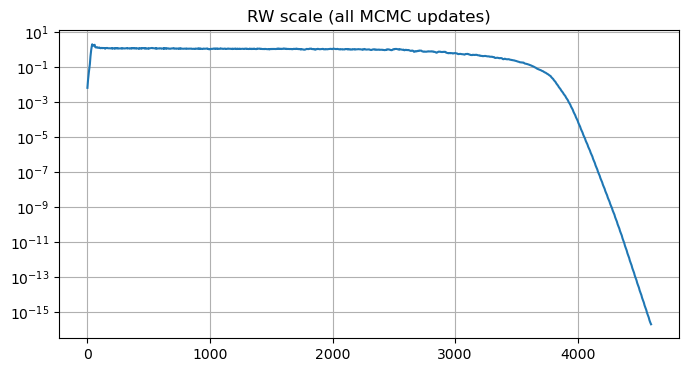

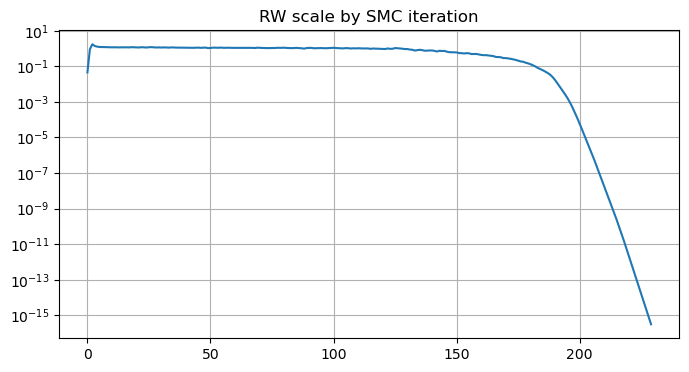

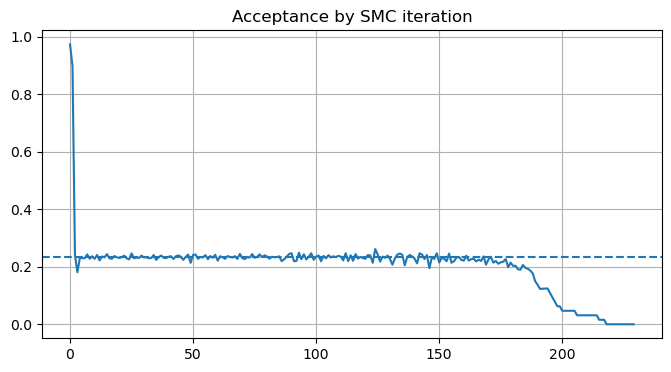

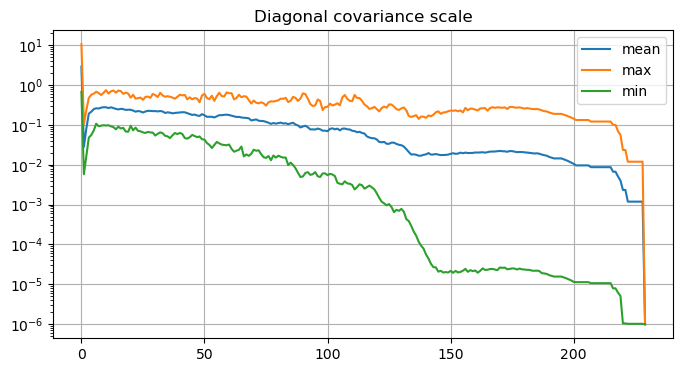

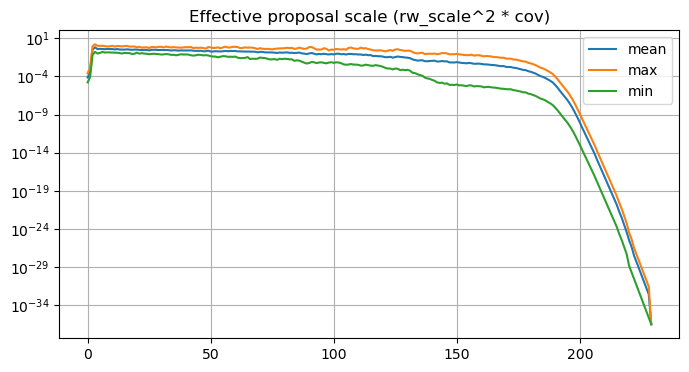

In [ ]:
#test eksperiment 3
import numpy as np
import matplotlib.pyplot as plt
import importlib

import reference
import targets
importlib.reload(reference)
importlib.reload(targets)

import jax
import jax.numpy as jnp
import blackjax
import blackjax.smc.resampling as resampling
import blackjax.smc.ess as smc_ess
import blackjax.smc.solver as smc_solver


def run_full_debug(target, num_particles=64, seed=0,
                   alpha=0.999, num_mcmc_steps=20,
                   rw_step_size=0.005,
                   diagonal_only_covariance=True):

    log_prior_fn = target.log_prior_fn
    log_likelihood_fn = target.log_likelihood_fn

    key = jax.random.PRNGKey(seed)
    key, init_key, run_key = jax.random.split(key, 3)
    initial_particles = target.sample_prior_fn(init_key, num_particles)

    state = blackjax.smc.tempered.init(initial_particles)
    work_dtype = initial_particles.dtype

    rw_scale = jnp.asarray(rw_step_size, dtype=work_dtype)

    proposal_cov = reference._empirical_covariance(
        initial_particles,
        diagonal_only=diagonal_only_covariance
    )

    base_rmh_kernel = blackjax.rmh.build_kernel()
    vmapped_log_likelihood_fn = jax.vmap(log_likelihood_fn)

    def tempered_logdensity_fn(beta):
        def _logdensity(theta):
            return log_prior_fn(theta) + beta * log_likelihood_fn(theta)
        return _logdensity

    def rmh_step_fn(rng_key, mcmc_state, logdensity_fn, rw_scale, proposal_cov):
        transition_generator = blackjax.mcmc.random_walk.normal(
            reference._proposal_sqrt_from_cov(proposal_cov, rw_scale)
        )
        return base_rmh_kernel(
            rng_key, mcmc_state, logdensity_fn,
            transition_generator=transition_generator,
        )

    vmapped_rmh_init = jax.vmap(
        lambda position, logdensity_fn: blackjax.rmh.init(position, logdensity_fn),
        in_axes=(0, None),
    )
    vmapped_rmh_step = jax.vmap(rmh_step_fn, in_axes=(0, 0, None, None, None))

    rw_scale_path = []
    acceptance_path = []
    diag_cov_path = []
    eff_diag_step_path = []

    n_iter = 0
    key = run_key

    while float(state.tempering_param) < 1.0 and n_iter < 10000:
        current_beta = jnp.asarray(state.tempering_param, dtype=work_dtype)

        one = jnp.asarray(1.0, dtype=work_dtype)
        zero = jnp.asarray(0.0, dtype=work_dtype)
        max_delta = one - current_beta

        delta_beta = smc_ess.ess_solver(
            vmapped_log_likelihood_fn,
            state.particles,
            jnp.asarray(alpha, dtype=work_dtype),
            max_delta,
            smc_solver.dichotomy,
        )
        delta_beta = jnp.clip(delta_beta, zero, max_delta)
        next_beta = current_beta + delta_beta

        # ---- record covariance BEFORE move
        diag_cov = np.asarray(jnp.diag(proposal_cov))
        diag_cov_path.append(diag_cov)
        eff_diag_step_path.append((float(rw_scale)**2) * diag_cov)

        # ---- resample
        current_loglik = vmapped_log_likelihood_fn(state.particles)
        w = jax.nn.softmax(delta_beta * current_loglik)

        key, resample_key = jax.random.split(key)
        ancestors = resampling.systematic(
            resample_key, w, state.particles.shape[0]
        )
        particles = state.particles[ancestors]

        next_logdensity_fn = tempered_logdensity_fn(next_beta)
        mcmc_states = vmapped_rmh_init(particles, next_logdensity_fn)

        # ---- MCMC moves
        for mcmc_iter in range(num_mcmc_steps):
            key, step_key = jax.random.split(key)
            keys = jax.random.split(step_key, particles.shape[0])

            mcmc_states, info = vmapped_rmh_step(
                keys, mcmc_states,
                next_logdensity_fn,
                rw_scale,
                proposal_cov,
            )

            acc = float(reference._safe_mean_acceptance(info))
            acceptance_path.append(acc)

            if not np.isnan(acc):
                rw_scale = reference._update_rw_scale_robbins_monro(
                    rw_scale,
                    acc,
                    0.234,
                    mcmc_iter + 1,
                )

            rw_scale_path.append(float(rw_scale))

        particles = mcmc_states.position

        state = blackjax.smc.tempered.TemperedSMCState(
            particles=particles,
            weights=jnp.ones((particles.shape[0],), dtype=work_dtype) / particles.shape[0],
            tempering_param=next_beta,
        )

        proposal_cov = reference._empirical_covariance(
            state.particles,
            diagonal_only=diagonal_only_covariance
        )

        n_iter += 1

    return {
        "rw_scale": np.array(rw_scale_path),
        "acceptance": np.array(acceptance_path),
        "diag_cov": np.array(diag_cov_path),
        "eff_step": np.array(eff_diag_step_path),
        "n_iter": n_iter,
        "num_mcmc_steps": num_mcmc_steps,
    }


# ============================
# RUN DEBUG
# ============================

target_lr = targets.make_sparse_logistic_regression_target(
    X=X,
    y=y,
    add_intercept=True,
    standardize=True,
)

dbg = run_full_debug(target_lr)


# ============================
# TEST 1: RW SCALE + ACCEPTANCE
# ============================

rw = dbg["rw_scale"]
acc = dbg["acceptance"]

plt.figure(figsize=(8,4))
plt.plot(rw)
plt.yscale("log")
plt.title("RW scale (all MCMC updates)")
plt.grid(True)
plt.show()


rw_by_iter = rw.reshape(dbg["n_iter"], dbg["num_mcmc_steps"])
acc_by_iter = acc.reshape(dbg["n_iter"], dbg["num_mcmc_steps"])

plt.figure(figsize=(8,4))
plt.plot(rw_by_iter.mean(axis=1))
plt.yscale("log")
plt.title("RW scale by SMC iteration")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(acc_by_iter.mean(axis=1))
plt.axhline(0.234, linestyle="--")
plt.title("Acceptance by SMC iteration")
plt.grid(True)
plt.show()


# ============================
# TEST 2: COVARIANCE SCALE
# ============================

diag_cov = dbg["diag_cov"]

plt.figure(figsize=(8,4))
plt.plot(diag_cov.mean(axis=1), label="mean")
plt.plot(diag_cov.max(axis=1), label="max")
plt.plot(diag_cov.min(axis=1), label="min")
plt.yscale("log")
plt.legend()
plt.title("Diagonal covariance scale")
plt.grid(True)
plt.show()


# ============================
# TEST 2b: EFFECTIVE STEP SIZE
# ============================

eff = dbg["eff_step"]

plt.figure(figsize=(8,4))
plt.plot(eff.mean(axis=1), label="mean")
plt.plot(eff.max(axis=1), label="max")
plt.plot(eff.min(axis=1), label="min")
plt.yscale("log")
plt.legend()
plt.title("Effective proposal scale (rw_scale^2 * cov)")
plt.grid(True)
plt.show()

In [ ]:
import importlib
import reference
importlib.reload(reference)

out_lr_256 = reference.run_reference_sampler_once(
    dimension=None,
    num_particles=256,
    seed=0,
    target_name="sparse_logistic_regression",
    target_kwargs={
        "X": X,
        "y": y,
        "add_intercept": True,
        "standardize": True,
    },
    alpha=0.999,
    num_mcmc_steps=20,
    rw_step_size=0.005,
    diagonal_only_covariance=False,
    covariance_ridge=1e-4,
    return_diagnostics=True,
)

In [46]:
import importlib
import numpy as np

import targets
import samplers

importlib.reload(targets)
importlib.reload(samplers)

# build sparse logistic target
target_lr = targets.make_sparse_logistic_regression_target(
    X=X,
    y=y,
    add_intercept=True,
    standardize=True,
)

def print_run_summary(out):
    print("target_name:", out["target_name"])
    print("kernel_name:", out["kernel_name"])
    print("seed:", out["seed"])
    print("logZ:", out["logZ"])
    print("n_iter:", out["n_iter"])
    print("runtime_sec:", out["runtime_sec"])
    print("final_ess:", out["final_ess"])
    print("acceptance_rate_mean:", out["acceptance_rate_mean"])
    print("posterior_mean shape:", out["posterior_mean"].shape)
    print("posterior_second_moment shape:", out["posterior_second_moment"].shape)

    if "step_size_path" in out:
        arr = np.asarray(out["step_size_path"], dtype=float)
        if arr.size > 0:
            print("last step_size:", arr[-1])

    if "L_path" in out:
        arr = np.asarray(out["L_path"], dtype=float)
        if arr.size > 0:
            print("last L:", arr[-1])

out_mala = samplers.run_ps_mala_once(
    dimension=target_lr.dimension,
    num_particles=256,
    seed=0,
    target=target_lr,
    alpha=0.999,
    num_mcmc_steps=25,
    step_size=0.01,
    target_acceptance_rate=0.574,
)

print_run_summary(out_mala)

target_name: sparse_logistic_regression
kernel_name: mala
seed: 0
logZ: -515.3304765288392
n_iter: 18
runtime_sec: 106.63169941600063
final_ess: 658.9686889648438
acceptance_rate_mean: 0.5765225556161668
posterior_mean shape: (51,)
posterior_second_moment shape: (51,)
last step_size: 0.0024181657936424017


In [61]:
from pathlib import Path
import importlib
import reference
importlib.reload(reference)

checkpoint_path = Path("../data/results/reference/checkpoints/sparse_logistic_smc_mala_N256_test.json")
save_final_path = Path("../data/results/reference/summary/sparse_logistic_smc_mala_N256_test.json")

ref_smc_mala = reference.build_reference_stats_chunked(
    dimension=None,
    num_particles_reference=256,
    num_reference_runs=5,
    target_name="sparse_logistic_regression",
    target_kwargs={
        "X": X,
        "y": y,
        "add_intercept": True,
        "standardize": True,
    },
    chunk_size=5,
    max_iterations=10_000,
    alpha=0.999,
    num_mcmc_steps=25,
    kernel_name="mala",
    mala_step_size=0.02,
    mala_target_acceptance_rate=0.574,
    mala_rm_c=2.0,
    mala_rm_t0=1.0,
    mala_rm_kappa=0.6,
    parallel=True,
    num_workers=5,   # reduce to 2 or 3 if your laptop gets overloaded
    checkpoint_path=checkpoint_path,
    save_final_path=save_final_path,
    verbose=True,
)

print(ref_smc_mala)


Running reference chunk seeds 0:5
Run 1/5 completed (seed=2) | elapsed=796.2s | ETA=3184.7s
Run 2/5 completed (seed=4) | elapsed=805.6s | ETA=1208.5s
Run 3/5 completed (seed=3) | elapsed=805.7s | ETA=537.1s
Run 4/5 completed (seed=1) | elapsed=806.9s | ETA=201.7s
Run 5/5 completed (seed=0) | elapsed=811.8s | ETA=0.0s
Checkpoint saved to ../data/results/reference/checkpoints/sparse_logistic_smc_mala_N256_test.json
Final reference stats saved to ../data/results/reference/summary/sparse_logistic_smc_mala_N256_test.json
ReferenceStats(target_name='sparse_logistic_regression', dimension=51, num_reference_runs=5, num_particles_reference=256, logZ_ref_mean=-516.0657423778816, logZ_ref_std=0.21699740155310257, f1_mean_ref=array([-1.15654809, -1.39069308, -1.1889418 ,  1.03536179, -1.0311587 ,
        0.40561262, -1.00807878, -0.62653906, -0.63248401,  0.0445256 ,
        0.69657589, -0.41073137, -0.79137761,  0.30409451,  0.05106022,
       -0.35021657, -0.79374916,  0.93960975, -0.88790252,  

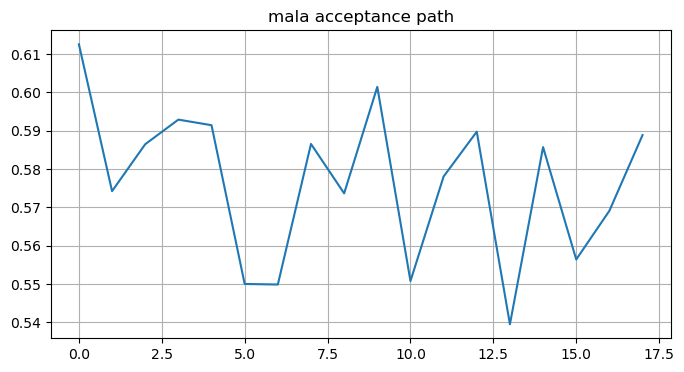

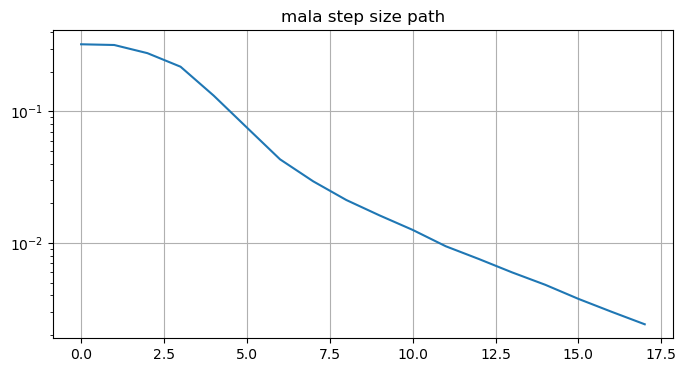

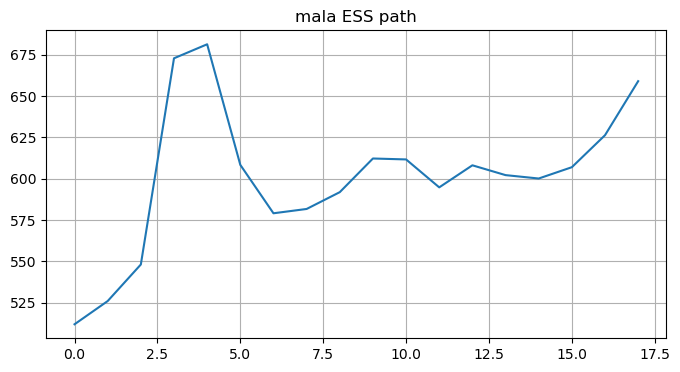

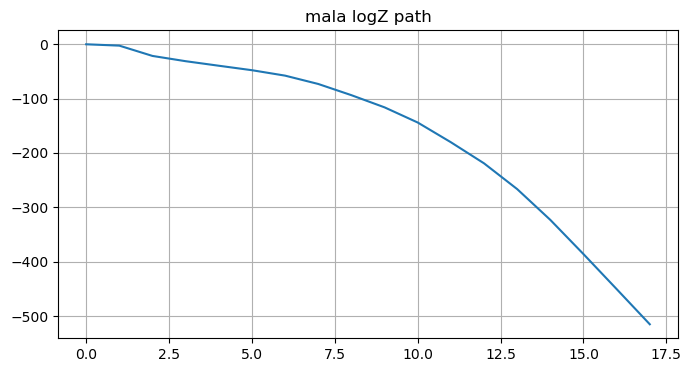

In [47]:
import matplotlib.pyplot as plt
import numpy as np

def plot_basic_paths(out, title=None):
    title = title or out["kernel_name"]

    if "acceptance_path" in out:
        plt.figure(figsize=(8, 4))
        plt.plot(np.asarray(out["acceptance_path"], dtype=float))
        plt.title(f"{title} acceptance path")
        plt.grid(True)
        plt.show()

    if "step_size_path" in out:
        arr = np.asarray(out["step_size_path"], dtype=float)
        if arr.size > 0 and np.all(np.isfinite(arr)):
            plt.figure(figsize=(8, 4))
            plt.plot(arr)
            plt.yscale("log")
            plt.title(f"{title} step size path")
            plt.grid(True)
            plt.show()

    if "ess_path" in out:
        plt.figure(figsize=(8, 4))
        plt.plot(np.asarray(out["ess_path"], dtype=float))
        plt.title(f"{title} ESS path")
        plt.grid(True)
        plt.show()

    if "logZ_path" in out:
        plt.figure(figsize=(8, 4))
        plt.plot(np.asarray(out["logZ_path"], dtype=float))
        plt.title(f"{title} logZ path")
        plt.grid(True)
        plt.show()

plot_basic_paths(out_mala)
    

In [25]:
import importlib
import reference
importlib.reload(reference)

out_lr = reference.run_reference_sampler_once(
    dimension=None,
    num_particles=64,
    seed=0,
    target_name="sparse_logistic_regression",
    target_kwargs={ "X": X,
                    "y": y,
                    "add_intercept": True,
                    "standardize": True,},
    alpha=0.999,
    num_mcmc_steps=20,
    rw_step_size=0.005,
    diagonal_only_covariance=True,
    rw_scale_min=1e-3,
    freeze_adaptation_beta=0.7,
    return_diagnostics=True,)

In [49]:
from pathlib import Path
import pandas as pd
import importlib

import reference
importlib.reload(reference)

base_dir = Path("../data/results/mac_reference_runs")

rows = []
for path in sorted(base_dir.glob("*/summary.json")):
    ref = reference.load_reference_stats(path)
    rows.append({
        "experiment": path.parent.name,
        "target": ref.target_name,
        "dimension": ref.dimension,
        "runs": ref.num_reference_runs,
        "N": ref.num_particles_reference,
        "logZ_mean": ref.logZ_ref_mean,
        "logZ_std": ref.logZ_ref_std,
        "ESS_mean": ref.final_ess_mean,
        "ESS_std": ref.final_ess_std,
        "acc_mean": ref.acceptance_rate_mean,
        "acc_std": ref.acceptance_rate_std,
        "n_iter_mean": ref.n_iter_mean,
        "n_iter_std": ref.n_iter_std,
    })

df = pd.DataFrame(rows).sort_values(["target", "dimension", "N"])
display(df)

,experiment,target,dimension,runs,N,logZ_mean,logZ_std,ESS_mean,ESS_std,acc_mean,acc_std,n_iter_mean,n_iter_std
1,gaussian_mixture_d10_N64_k25_R1,gaussian_mixture,10,1,64,-23.190383,0.000000,63.997110,0.000000,0.234689,0.000000,185.0,0.000000
0,gaussian_mixture_d10_N256_k50_R5,gaussian_mixture,10,5,256,-23.679317,0.033441,255.877093,0.084451,0.234272,0.000088,187.4,1.140175
2,gaussian_mixture_d50_N128_k25_R1,gaussian_mixture,50,1,128,-83.191897,0.000000,127.939826,0.000000,0.234080,0.000000,301.0,0.000000
4,rosenbrock_d10_N64_k25_R1,rosenbrock,10,1,64,-15.568035,0.000000,63.995629,0.000000,0.234315,0.000000,279.0,0.000000
3,rosenbrock_d10_N256_k100_R5,rosenbrock,10,5,256,-15.971535,0.056075,255.920019,0.092671,0.234058,0.000060,293.8,1.303840
5,rosenbrock_d50_N128_k25_R1,rosenbrock,50,1,128,-46.480159,0.000000,127.935517,0.000000,0.234168,0.000000,311.0,0.000000


In [54]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import reference
importlib.reload(reference)

# ----------------------------
# Load all finished summary files
# ----------------------------
base_dir = Path("../data/results/mac_reference_runs")

rows = []
for path in sorted(base_dir.glob("*/summary.json")):
    ref = reference.load_reference_stats(path)
    rows.append({
        "experiment": path.parent.name,
        "target": ref.target_name,
        "dimension": ref.dimension,
        "N": ref.num_particles_reference,
        "runs": ref.num_reference_runs,
        "logZ_mean": ref.logZ_ref_mean,
        "logZ_std": ref.logZ_ref_std,
        "ESS_mean": ref.final_ess_mean,
        "ESS_std": ref.final_ess_std,
        "ESS_frac": ref.final_ess_mean / ref.num_particles_reference,
        "acc_mean": ref.acceptance_rate_mean,
        "acc_std": ref.acceptance_rate_std,
        "n_iter_mean": ref.n_iter_mean,
        "n_iter_std": ref.n_iter_std,
        "summary_path": str(path),
    })

In [59]:
df["experiment"]

0     gaussian_mixture_d10_N256_k50_R5
1      gaussian_mixture_d10_N64_k25_R1
2     gaussian_mixture_d50_N128_k25_R1
3    gaussian_mixture_d50_N512_k100_R5
4          rosenbrock_d10_N256_k100_R5
5            rosenbrock_d10_N64_k25_R1
6           rosenbrock_d50_N128_k25_R1
7          rosenbrock_d50_N512_k150_R5
Name: experiment, dtype: str

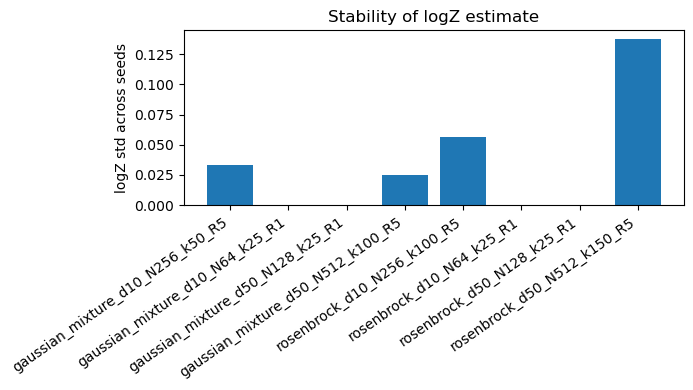

In [60]:
df = pd.DataFrame(rows)
plt.figure(figsize=(7,4))
plt.bar(df["experiment"], df["logZ_std"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("logZ std across seeds")
plt.title("Stability of logZ estimate")
plt.tight_layout()
plt.show()

In [67]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

base_dir = Path("../data/results/mac_reference_runs")
sparse_summary_path = Path("../data/results/reference/summary/sparse_logistic_smc_mala_N256_test.json")

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def is_reference_summary(d):
    required = [
        "target_name",
        "dimension",
        "num_reference_runs",
        "num_particles_reference",
        "logZ_ref_mean",
        "logZ_ref_std",
        "final_ess_mean",
        "acceptance_rate_mean",
        "n_iter_mean",
    ]
    return all(k in d for k in required)

def summarize_ref_json(path, method):
    d = load_json(path)

    if not is_reference_summary(d):
        return None

    return {
        "file": str(path),
        "target": d["target_name"],
        "method": method,
        "dimension": d["dimension"],
        "N": d["num_particles_reference"],
        "runs": d["num_reference_runs"],
        "logZ_mean": d["logZ_ref_mean"],
        "logZ_std": d["logZ_ref_std"],
        "ESS_mean": d["final_ess_mean"],
        "ESS_std": d["final_ess_std"],
        "accept_mean": d["acceptance_rate_mean"],
        "accept_std": d["acceptance_rate_std"],
        "n_iter_mean": d["n_iter_mean"],
        "n_iter_std": d["n_iter_std"],
    }

rows = []

# only read likely final summary files, not checkpoints
for p in sorted(base_dir.rglob("*.json")):
    if "checkpoint" in str(p).lower() or "checkpoints" in str(p).lower():
        continue

    row = summarize_ref_json(p, method="SMC + RWM")
    if row is not None:
        rows.append(row)

# add sparse logistic SMC + MALA
row = summarize_ref_json(sparse_summary_path, method="SMC + MALA")
if row is not None:
    rows.append(row)

df_ref = pd.DataFrame(rows)

# remove exact duplicates
df_ref = df_ref.drop_duplicates(
    subset=["target", "method", "dimension", "N", "runs", "logZ_mean", "logZ_std"]
)

# remove incomplete rows
df_ref = df_ref.dropna(subset=["logZ_mean", "ESS_mean", "accept_mean", "n_iter_mean"])

df_ref = df_ref.sort_values(["target", "dimension", "N", "method"]).reset_index(drop=True)

df_filtered = df_ref[df_ref['runs'] == 5]

In [68]:
df_filtered

,file,target,method,dimension,N,runs,logZ_mean,logZ_std,ESS_mean,ESS_std,accept_mean,accept_std,n_iter_mean,n_iter_std
1,../data/results/mac_reference_runs/gaussian_mi...,gaussian_mixture,SMC + RWM,10,256,5,-23.679317,0.033441,255.877093,0.084451,0.234272,0.000088,187.4,1.140175
3,../data/results/mac_reference_runs/gaussian_mi...,gaussian_mixture,SMC + RWM,50,512,5,-93.812343,0.024928,511.839073,0.174900,0.233854,0.000024,315.4,0.547723
5,../data/results/mac_reference_runs/rosenbrock_...,rosenbrock,SMC + RWM,10,256,5,-15.971535,0.056075,255.920019,0.092671,0.234058,0.000060,293.8,1.303840
7,../data/results/mac_reference_runs/rosenbrock_...,rosenbrock,SMC + RWM,50,512,5,-51.518195,0.137807,511.826832,0.178044,0.233962,0.000030,347.8,0.836660
8,../data/results/reference/summary/sparse_logis...,sparse_logistic_regression,SMC + MALA,51,256,5,-516.065742,0.216997,255.931592,0.086230,0.573920,0.000057,436.2,3.633180


target: sparse_logistic_regression
kernel: mala
dimension: 51
logZ: -516.0556699242168
n_iter: 441
final_ess: 255.79580841968505
acceptance_rate_mean: 0.5739951124990955
final_step_size: 0.002538219307776575


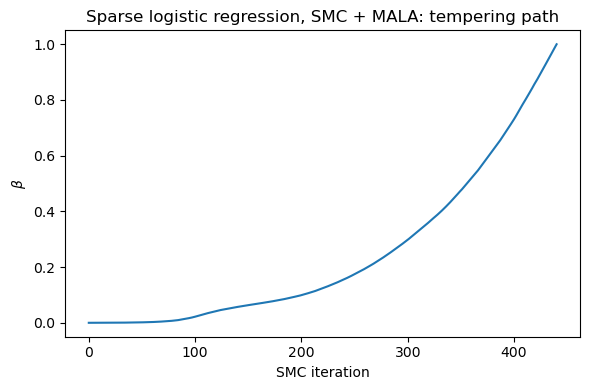

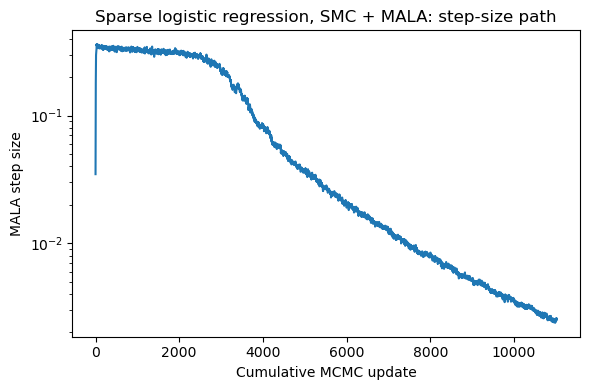

In [71]:
import importlib
import matplotlib.pyplot as plt

import reference
importlib.reload(reference)

# X and y must already be loaded.
# Example:
# X = ...
# y = ...

slr_mala_out = reference.run_reference_sampler_once(
    dimension=None,
    num_particles=256,
    seed=0,
    target_name="sparse_logistic_regression",
    target_kwargs={
        "X": X,
        "y": y,
        "add_intercept": True,
        "standardize": True,
    },
    alpha=0.999,
    num_mcmc_steps=25,
    kernel_name="mala",
    mala_step_size=0.02,
    mala_target_acceptance_rate=0.574,
    return_diagnostics=True,
)

print("target:", slr_mala_out["target_name"])
print("kernel:", slr_mala_out["kernel_name"])
print("dimension:", slr_mala_out["dimension"])
print("logZ:", slr_mala_out["logZ"])
print("n_iter:", slr_mala_out["n_iter"])
print("final_ess:", slr_mala_out["final_ess"])
print("acceptance_rate_mean:", slr_mala_out["acceptance_rate_mean"])
print("final_step_size:", slr_mala_out["final_step_size"])

# ----------------------------
# Graph 1: tempering path
# ----------------------------
plt.figure(figsize=(6, 4))
plt.plot(slr_mala_out["tempering_path"])
plt.xlabel("SMC iteration")
plt.ylabel(r"$\beta$")
plt.title("Sparse logistic regression, SMC + MALA: tempering path")
plt.tight_layout()
plt.show()

# ----------------------------
# Graph 2: MALA step-size path
# ----------------------------
plt.figure(figsize=(6, 4))
plt.plot(slr_mala_out["step_size_path"])
plt.yscale("log")
plt.xlabel("Cumulative MCMC update")
plt.ylabel("MALA step size")
plt.title("Sparse logistic regression, SMC + MALA: step-size path")
plt.tight_layout()
plt.show()